# Image Preprocessing

Image preprocessing is a crucial step in machine learning workflows. Proper preprocessing improves model training stability, performance, and generalisation.

---

## Common Image Preprocessing Techniques

- **Color Space Conversion**  
  Convert images between color spaces such as RGB, Grayscale, HSV, or Lab.  
  Useful for reducing complexity or highlighting specific features.

- **Normalization**  
  Scale pixel values to a standard range like [0, 1] or [-1, 1].  
  Helps neural networks learn effectively.

- **Resize and Rescale**  
  Resize images to a fixed dimension to ensure uniform input size for models.

- **Cropping and Padding**  
  Crop images to focus on regions of interest or pad images to maintain aspect ratio.

- **Data Augmentation**  
  Apply random transformations like rotation, flipping, zooming, and shifting to increase dataset diversity and reduce overfitting.

- **Histogram Equalization**  
  Adjust image contrast to improve feature visibility.

- **Noise Reduction and Filtering**  
  Apply filters such as Gaussian blur to reduce noise.

- **Batch Processing**  
  Efficiently preprocess multiple images in batches.

In [ ]:
%pip install tensorflow

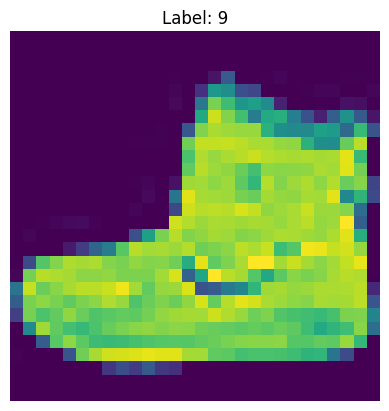

In [10]:
from tensorflow.keras.datasets import fashion_mnist
from PIL import Image, ImageFilter
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

(x_train, y_train), _ = fashion_mnist.load_data()
image_array = x_train[0]

plt.imshow(x_train[0])
plt.title(f"Label: {y_train[0]}")
plt.axis('off')
plt.show()

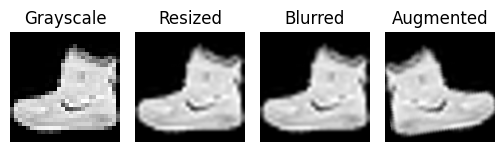

In [ ]:
# Grayscale
gray_image = Image.fromarray(image_array).convert("L") # L means grayscale
plt.subplot(1, 5, 2)
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale")
plt.axis('off')

# Resize
resized_image = gray_image.resize((224, 224))
plt.subplot(1, 5, 3)
plt.imshow(resized_image, cmap="gray")
plt.title("Resized")
plt.axis('off')

# Gaussian Blur
blurred_image = resized_image.filter(ImageFilter.GaussianBlur(radius=1))
plt.subplot(1, 5, 4)
plt.imshow(blurred_image, cmap="gray")
plt.title("Blurred")
plt.axis('off')

# Transformed Tensor
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
processed_tensor = transform(blurred_image)

# To display the transformed tensor
processed_image = processed_tensor * 0.5 + 0.5  # Undo normalization
np_image = processed_image.squeeze().numpy()

plt.subplot(1, 5, 5)
plt.imshow(np_image, cmap="gray")
plt.title("Augmented")
plt.axis('off')

plt.tight_layout()
plt.show()
